### Import libraries

In [1]:
import pandas as pd
import numpy as np
import re
import emoji
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter


nltk.download('punkt')
nltk.download('stopwords')

import emot

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('word_tokenize')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Error loading word_tokenize: Package 'word_tokenize' not
[nltk_data]     found in index


# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Pre-processing Post DataFrame </div>

In [3]:
posts_df = pd.read_csv(r'C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\clean\clean_posts.csv')
posts_df.head()

,post_id,timestamp,postUser,caption,hashtags,likesCount,commentsCount
0,1,2023-06-02 16:34:43+00:00,maryleest,Cannes 2023 with @kilianparis 🤍 #KilianCannes ...,KilianCannes,32070,142
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,"As the clock struck midnight to ring in 2022, ...",no_hashtag,6565,86
2,3,2023-05-29 18:57:51+00:00,maryleest,The famous stairs 🤎 Photo @gustave_durin Dre...,no_hashtag,28936,123
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,I visualized this moment so many times before....,CHANELFallWinter,4764,215
4,5,2023-05-23 21:11:12+00:00,maryleest,Got to witness such historical moment in cinem...,CannesFilmFestival,13379,123


In [4]:
# Type of each column
posts_df['timestamp'] = pd.to_datetime(posts_df['timestamp'])
posts_df.dtypes   

post_id                        int64
timestamp        datetime64[ns, UTC]
postUser                      object
caption                       object
hashtags                      object
likesCount                     int64
commentsCount                  int64
dtype: object

### "Caption" column 

In [5]:
def preprocess_caption(text):
    if pd.isna(text) or text == 'no_caption':
        return ""
    
    text = text.lower() # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^\w\s\U0001F000-\U0001F9FF]', ' ', text) # Keep alphanumeric, whitespace, and emoji characters, replace others with space
    text = re.sub(r'\s+', ' ', text).strip()  # Replace multiple spaces with a single space
    
    return text

posts_df['clean_caption'] = posts_df['caption'].apply(preprocess_caption)

In [6]:
# Process Emoji in caption
def process_emoji(text):
    """
    Process emojis in text.
    Returns text without emojis and list of emoji descriptions.
    If an emoji can't be processed, it's removed from the text.
    """
    emojis_list = [c for c in text if c in emoji.EMOJI_DATA]
    
    emoji_descriptions = []
    
    for e in emojis_list:
        try:
            emoji_name = emoji.demojize(e).replace(':', '').replace('_', ' ')
            emoji_descriptions.append(emoji_name)
        except Exception:
            # If an emoji can't be processed, it's removed from the text.
            continue
    
    text_without_emoji = ''.join(c for c in text if c not in emoji.EMOJI_DATA)
    
    return text_without_emoji, emoji_descriptions

posts_df[['caption_no_emoji', 'emoji_descriptions']] = posts_df['clean_caption'].apply(lambda x: pd.Series(process_emoji(x)))

### "Hashtags" column

In [7]:
# Process hashtags from hashtag column
def process_hashtags_from_column(hashtag_text):
    """
    Process hashtags from a text string into a list of individual words.
    
    Args:
        hashtag_text (str): Input text containing hashtags, either as a comma-separated string
                          or in bracket notation ['tag1', 'tag2']
    
    Returns:
        list: List of processed hashtag words in lowercase
        
    Examples:
        >>> process_hashtags_from_column("FashionWeek,SummerStyle")
        ['fashion', 'week', 'summer', 'style']
        >>> process_hashtags_from_column("['FashionWeek', 'SummerStyle']")
        ['fashion', 'week', 'summer', 'style']
    """
    if pd.isna(hashtag_text) or hashtag_text == 'no_hashtag' or hashtag_text == '':
        return []
    
    if hashtag_text.startswith('[') and hashtag_text.endswith(']'):
        hashtag_text = hashtag_text[1:-1]
        
        tags = [tag.strip().strip("'").strip('"') for tag in hashtag_text.split(',')]
    else:
        tags = [tag.strip().strip('#') for tag in re.split(r'[,#]', hashtag_text) if tag.strip()]
    
    processed_hashtags = []
    for tag in tags:
        if tag:
            words = re.findall(r'[A-Z]?[a-z]+|[A-Z]+(?=[A-Z]|$)', tag)
            if not words:
                words = [tag]
            processed_hashtags.extend([word.lower() for word in words])
    
    return processed_hashtags

posts_df['hashtags'] = posts_df['hashtags'].apply(process_hashtags_from_column)

In [8]:
# Tokenize and remove stopwords
import string

def tokenize_and_remove_stopwords(text):
    
    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if  word not in stop_words and word not in string.punctuation]
    
    return filtered_tokens

posts_df['caption_tokens'] = posts_df['caption_no_emoji'].apply(tokenize_and_remove_stopwords)

### Combined Tokens

In [9]:
# Define fashion-related keywords và exclusion patterns
FASHION_KEYWORDS = {
    'dress', 'shirt', 'jeans', 'hat', 'bag', 'shoe', 'boot', 'sandal', 'jacket',
    'coat', 'scarf', 'gloves', 'sunglasses', 'ring', 'necklace', 'bracelet',
    'purse', 'handbag', 'briefcase', 'clothing', 't-shirt', 'skirt', 'blouse',
    'sweater', 'hoodie', 'pants', 'shorts', 'belt', 'wallet', 'tie', 'watch',
    'heel', 'jewelry', 'accessory', 'outfit', 'fashion', 'style'
}
BAD_WORDS = ['symbol', 'button', 'square', 'hand', 'face', 'skin', 'flag', 'animal', 'gesture']

# Precompile regex patterns
BAD_PATTERN = re.compile(
    r'\b(' + '|'.join(map(re.escape, BAD_WORDS)) + r')\b', 
    flags=re.IGNORECASE
)

FASHION_PATTERN = re.compile(
    r'\b(?:{})\b'.format('|'.join(
        [re.escape(kw).replace('-', r'\-?') for kw in FASHION_KEYWORDS]
    )), 
    flags=re.IGNORECASE
)

In [10]:
# Filter fashion emojis
def filter_fashion_emojis(descriptions):
    """
    Remain emojis that are fashion-related or have 3 or fewer words and are not bad words
    """
    out = []
    for e in descriptions:
        if FASHION_PATTERN.search(e):
            out.append(e)
        else:
            # Count the number of words = number of spaces + 1
            if (e.count(' ') + 1) <= 3 and not BAD_PATTERN.search(e):
                out.append(e)
    return out

# Vectorized operations for combining tokens
posts_df['combined_tokens'] = (
    posts_df['caption_tokens'] 
    + posts_df['emoji_descriptions'].apply(filter_fashion_emojis)
    + posts_df['hashtags'] 
)

posts_df['token_text'] = posts_df['combined_tokens'].apply(lambda toks: ' '.join(toks))

In [11]:
def fashion_tokenizer(text):
    return text.split()

# Function to extract keywords
def extract_fashion_keywords(df, min_df=5, max_df=0.75, top_n=5):
    tfidf = TfidfVectorizer(
        min_df=min_df,
        max_df=max_df,
        ngram_range=(1, 2),
        tokenizer=fashion_tokenizer,
        analyzer='word',
        max_features=5000
    )
    
    X = tfidf.fit_transform(df['token_text'])
    features = np.array(tfidf.get_feature_names_out())
    
    # Function to get top_n terms
    def top_n_terms(row):
        if row.nnz == 0:
            return []
        idx = np.argsort(-row.data)[:top_n]
        return features[row.indices[idx]]
    
    # Function to check if term is a fashion keyword
    def is_fashion_kw(kw):
        parts = re.split(r'[\s-]', kw.lower())
        return any(p in FASHION_KEYWORDS for p in parts)
    
    # Initialize list-of-lists with correct length
    all_keywords = [[] for _ in range(df.shape[0])]
    
    # Fill each row
    for i, row in enumerate(X):
        candidates = top_n_terms(row)
        filtered = [kw for kw in candidates if is_fashion_kw(kw)]
        all_keywords[i] = filtered[:top_n]
    
    # Assign to DataFrame
    df = df.copy()  # avoid unintended changes
    df['fashion_keywords'] = all_keywords
    
    return df, tfidf

posts_df, tfidf_model = extract_fashion_keywords(posts_df)

print(posts_df[['combined_tokens', 'fashion_keywords']].head())

                                     combined_tokens     fashion_keywords
0  [cannes, 2023, kilianparis, kiliancannes, wear...              [dress]
1  [clock, struck, midnight, ring, 2022, cried, w...                   []
2  [famous, stairs, photo, gustave_durin, dress, ...  [dress marmarhalim]
3  [visualized, moment, many, times, first, chane...                   []
4  [got, witness, historical, moment, cinema, kil...                   []


c:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\venv\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [12]:
def extract_keywords_frequency(df, top_n=5):
    """Extract keywords based on frequency of occurrence"""
    def get_frequent_keywords(tokens, n=top_n):
        # Count frequency
        counter = Counter(tokens)
        
        # Get most frequent keywords
        return [word for word, count in counter.most_common(n)]
    
    # Apply to each post
    df['keywords_freq'] = df['combined_tokens'].apply(get_frequent_keywords)
    
    return df

posts_df = extract_keywords_frequency(posts_df)

In [13]:
important_categories = {
    'events': [
        'cannes', 'festival', 'gala', 'premiere', 'show', 'fashionweek', 
        'metgala', 'runway', 'awards', 'ceremony', 'redcarpet', 'exclusiveevent',
        'cannesfilmfestival', 'parisfashionweek', 'mfw', 'pfw', 'nyfw', 'lfw'
    ],
    'years': [str(y) for y in range(2018, 2026)],
    'brands': [
        'kilian', 'dior', 'chanel', 'gucci', 'louisvuitton', 'prada', 'adidas',
        'versace', 'fendi', 'burberry', 'hermes', 'armani', 'givenchy', 
        'balenciaga', 'valentino', 'saintlaurent', 'bottegaveneta', 'celine', 
        'loewe', 'moschino', 'alexandermcqueen', 'offwhite', 'ysl', 'miu', 'ganni'
    ],
    'fashion': [
        'wear', 'dress', 'style', 'outfit', 'fashion', 'trend', 'runwaylook', 
        'couture', 'chic', 'glamour', 'haute', 'streetstyle', 'accessories', 
        'shoes', 'handbag', 'jewelry', 'luxuryfashion', 'editorial', 'aesthetic',
        'designer', 'minimal', 'maximal', 'vintage', 'avantgarde', 'moda', 'looks'
    ],
    'locations': [
        'paris', 'milan', 'london', 'newyork', 'tokyo', 'losangeles', 
        'berlin', 'barcelona', 'dubai', 'hongkong', 'seoul', 'copenhagen'
    ]
}

category_weights = {
    'events': 3.0,
    'years': 1.5,
    'brands': 2.5,
    'fashion': 2.0,
    'locations': 2.2
}

# Precompile list of (regex, weight) tuples
_pattern_weights = []
for cat, terms in important_categories.items():
    weight = category_weights.get(cat, 1.0)
    # \b(?:term1|term2|...)\b, ignore case
    pat = re.compile(r'\b(?:' + '|'.join(map(re.escape, terms)) + r')\b', re.IGNORECASE)
    _pattern_weights.append((pat, weight))


def extract_weighted_keywords(df: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    """
    For each row of df['combined_tokens'], calculate score token = product of matched category_weights.
    Return df with an additional column 'keywords_weighted'.
    """
    def _score_and_select(tokens):
        # Remove duplicates to avoid recalculating
        uniq_tokens = list(dict.fromkeys(tokens))
        scores = {tok: 1.0 for tok in uniq_tokens}

        # Multiply weight if any pattern matches
        for pat, w in _pattern_weights:
            for tok in uniq_tokens:
                if pat.search(tok):
                    scores[tok] *= w

        # Sort by score desc, if score is the same, keep original order
        ranked = sorted(uniq_tokens, key=lambda t: scores[t], reverse=True)
        return ranked[:top_n]

    return df.assign(
        keywords_weighted = df['combined_tokens'].apply(_score_and_select)
    )

posts_df = extract_weighted_keywords(posts_df)

print(posts_df[['combined_tokens', 'keywords_weighted']].head(5))

                                     combined_tokens  \
0  [cannes, 2023, kilianparis, kiliancannes, wear...   
1  [clock, struck, midnight, ring, 2022, cried, w...   
2  [famous, stairs, photo, gustave_durin, dress, ...   
3  [visualized, moment, many, times, first, chane...   
4  [got, witness, historical, moment, cinema, kil...   

                                   keywords_weighted  
0         [cannes, kilian, dress, 2023, kilianparis]  
1              [2022, 2023, clock, struck, midnight]  
2            [dress, jewelry, famous, stairs, photo]  
3         [show, chanel, fashion, shoes, visualized]  
4  [cannes, cannesfilmfestival, festival, got, wi...  


In [14]:
def merge_keywords(row):
    merged = []
    seen = set()
    
    # Weighted > freq > tf-idf
    for col in ['keywords_weighted', 'keywords_freq', 'fashion_keywords']:
        for token in row[col]:
            if token not in seen:
                seen.add(token)
                merged.append(token)
    
    return merged

# Apply merge
posts_df['combined_keywords'] = posts_df.apply(merge_keywords, axis=1)


In [15]:
processed_posts_df = posts_df[['post_id', 'postUser', 'timestamp','likesCount', 'commentsCount', 'combined_keywords']]
# Rename "combined_keyword" column
processed_posts_df.rename(columns={"combined_keywords": "keywords_posts"}, inplace=True)
processed_posts_df.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10748\1503452877.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_posts_df.rename(columns={"combined_keywords": "keywords_posts"}, inplace=True)


,post_id,postUser,timestamp,likesCount,commentsCount,keywords_posts
0,1,maryleest,2023-06-02 16:34:43+00:00,32070,142,"[cannes, kilian, dress, 2023, kilianparis, kil..."
1,2,tinaabeysekara,2023-01-01 07:49:16+00:00,6565,86,"[2022, 2023, clock, struck, midnight, year, ev..."
2,3,maryleest,2023-05-29 18:57:51+00:00,28936,123,"[dress, jewelry, famous, stairs, photo, gustav..."
3,4,stephaniebroek,2023-03-07 19:30:42+00:00,4764,215,"[show, chanel, fashion, shoes, visualized, edi..."
4,5,maryleest,2023-05-23 21:11:12+00:00,13379,123,"[cannes, cannesfilmfestival, festival, got, wi..."


In [16]:
#processed_posts_df.to_csv('processed_posts_df.csv', index=False)

# <div style="text-align: center; background-color: white; font-family: Lobster;color: black; padding: 14px; line-height: 1;border-radius:12px"> Pre-processing "Comments.csv" </div>

````

In [17]:
comments_df = pd.read_csv(r'C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\clean\clean_comments.csv')
comments_df.head()

,post_id,commentUser,timestamp,comments,likes
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,"I have a proposal for u, send me a DM please!",0.0
1,1,mariavmh,2023-06-04 16:46:40+00:00,Woaaaah,0.0
2,1,mariavmh,2023-06-04 16:46:34+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,:red_heart:️:red_heart:️:red_heart:️,0.0
4,1,jillviv,2023-06-04 15:06:03+00:00,:smiling_face_with_heart-eyes::smiling_face_wi...,0.0


In [18]:
print("Number of comment:", comments_df['comments'].notnull().sum())
comments_df['timestamp'] = pd.to_datetime(comments_df['timestamp'])

Number of comment: 5361


In [19]:
comments_df.dtypes

post_id                      int64
commentUser                 object
timestamp      datetime64[ns, UTC]
comments                    object
likes                      float64
dtype: object

In [20]:
import re
import emoji

def clean_comment(comment):
    # Replace special character by space
    if pd.isna(comment) or comment == 'no_comment' or comment == '':
        return ""
    comment = comment.lower()
    comment = re.sub(r'http\S+|www\S+|https\S+', '', comment)
    comment = re.sub(r'[^\w\s]', ' ', comment)
    comment = re.sub(r'\d+', '', comment)
    comment = re.sub(r'\s+', ' ', comment).strip()
    return comment

comments_df['clean_comment'] = comments_df['comments'].astype(str).apply(clean_comment)

In [21]:
stop_words = set(stopwords.words('english'))
def preprocess_comment(text: str) -> list:
    
    tokens = word_tokenize(text)
    return [word for word in tokens if word not in stop_words]


comments_df['tokens'] = comments_df['clean_comment'].apply(preprocess_comment)

In [22]:
comments_df = comments_df.copy()
comments_df.drop(columns=['comments'], inplace=True)
comments_df.head()

,post_id,commentUser,timestamp,likes,clean_comment,tokens
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,0.0,i have a proposal for u send me a dm please,"[proposal, u, send, dm, please]"
1,1,mariavmh,2023-06-04 16:46:40+00:00,0.0,woaaaah,[woaaaah]
2,1,mariavmh,2023-06-04 16:46:34+00:00,0.0,smiling_face_with_heart eyes smiling_face_with...,"[smiling_face_with_heart, eyes, smiling_face_w..."
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,0.0,red_heart red_heart red_heart,"[red_heart, red_heart, red_heart]"
4,1,jillviv,2023-06-04 15:06:03+00:00,0.0,smiling_face_with_heart eyes smiling_face_with...,"[smiling_face_with_heart, eyes, smiling_face_w..."


## Segtiment Analysis

In [23]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load pre-trained transformer
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [24]:
labels = ['negative', 'neutral', 'positive']

def analyze_sentiment_batch(texts, batch_size=32, max_length=256):
    results = []

    # Clean text and convert emoji alias → unicodes
    cleaned_texts = [
        emoji.emojize(str(text).strip(), language='alias') if isinstance(text, str) else ''
        for text in texts
    ]

    # batch
    for i in range(0, len(cleaned_texts), batch_size):
        batch = cleaned_texts[i:i+batch_size]
        
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=max_length
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        polarities = probs[:, 2] - probs[:, 0]  # positive - negative
        sentiments = torch.argmax(probs, dim=1)

        for p, s in zip(polarities.cpu().numpy(), sentiments.cpu().numpy()):
            results.append({
                'polarity': round(float(p), 4),
                'sentiment': labels[s]
            })
    
    return pd.DataFrame(results)

In [25]:
sentiment_df = analyze_sentiment_batch(comments_df['clean_comment'].tolist(), batch_size=64)

comments_df = pd.concat([comments_df.reset_index(drop=True), sentiment_df], axis=1)

c:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\venv\lib\site-packages\transformers\models\roberta\modeling_roberta.py:370: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


In [26]:
import re

emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # Emoticons
    u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # Transport & map symbols
    u"\U0001F1E0-\U0001F1FF"  # Flags (iOS)
    "]+", 
    flags=re.UNICODE
)

def extract_keywords_tfidf_preserve_emoji(corpus, n=5):
    
    custom_stop_words = set(stopwords.words('english'))
    custom_stop_words = [word for word in custom_stop_words if not re.match(emoji_pattern, word)]
    
    # TfidfVectorizer
    vectorizer = TfidfVectorizer(
        max_features=1000,
        stop_words=list(custom_stop_words),
        use_idf=True,
        norm='l2',
        min_df=0.01,
        max_df=0.9
    )
    
    # check if corpus has no text
    if all(not text for text in corpus):
        return [[] for _ in range(len(corpus))]
    
    # create tfidf matrix
    tfidf_matrix = vectorizer.fit_transform(corpus)
    
    # get feature names (words)
    feature_names = vectorizer.get_feature_names_out()
    
    # extract keywords for each text
    keywords_list = []
    for i in range(tfidf_matrix.shape[0]):
        # if text is empty, return empty list
        if not corpus[i]:
            keywords_list.append([])
            continue
        
        # get tfidf scores for current text
        tfidf_scores = tfidf_matrix[i].toarray()[0]
        
        # combine word and tfidf score
        word_scores = [(feature_names[j], tfidf_scores[j]) for j in range(len(feature_names))]
        
        # sort by tfidf score in descending order
        word_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Lấy n từ khóa hàng đầu (chỉ lấy từ, không lấy điểm)
        top_keywords = [word for word, _ in word_scores[:n]]
        keywords_list.append(top_keywords)
    
    return keywords_list


In [27]:
clean_comments = comments_df['clean_comment'].tolist()
tfidf_keywords = extract_keywords_tfidf_preserve_emoji(clean_comments)
comments_df['tfidf_keywords'] = tfidf_keywords

In [28]:
import re
from collections import Counter

# Regex phát hiện emoji (bao gồm cả biến thể màu da và flags)
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # Emoticons
    u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # Transport & map symbols
    u"\U0001F1E0-\U0001F1FF"  # Flags (iOS)
    u"\U00002702-\U000027B0"  # Dingbats
    u"\U000024C2-\U0001F251"  # Enclosed characters
    "]+", 
    flags=re.UNICODE
)

# Thêm cột 'emoji_present' vào DataFrame
comments_df['emoji_present'] = comments_df['clean_comment'].apply(
    lambda x: emoji_pattern.findall(x) if isinstance(x, str) else []
)

print("\nEffect of emoji on sentiment:")
for sentiment, group in comments_df.groupby('sentiment'):
    all_emojis = [emoji for sublist in group['emoji_present'] for emoji in sublist]
    print(f"{sentiment}: {Counter(all_emojis).most_common(5)}")  # Top 5 emoji phổ biến


Effect of emoji on sentiment:
negative: [('𒁎𒌧𒁎𒁎𒁎𒁎𒁎𒌧𒁎𒁎𒁎𒁎𒁎𒁎𒌧𒌧𒌧𒁎𒁎𒌧𒌧𒁎𒁎', 1)]
neutral: [('ꜱ', 40), ('ꜰ', 16), ('𝑫𝑴', 8), ('𝐈', 7), ('ꜱꜱ', 7)]
positive: [('도겸', 1)]


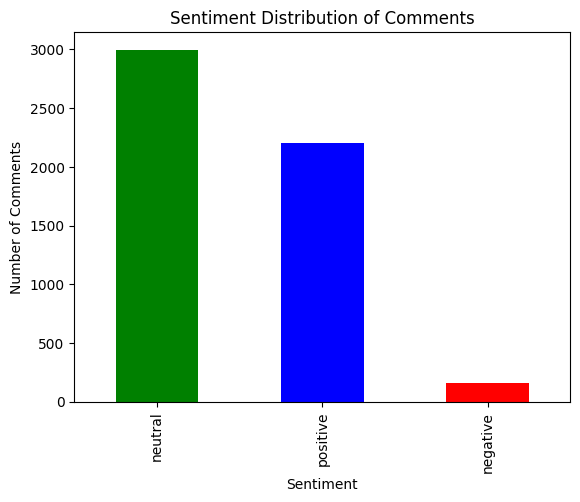

In [29]:
import matplotlib.pyplot as plt

# Count the number of comments for each sentiment label
sentiment_counts = comments_df['sentiment'].value_counts()
sentiment_counts.plot(kind='bar', color=['green', 'blue', 'red'])
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.title('Sentiment Distribution of Comments')
plt.show()


### EDA

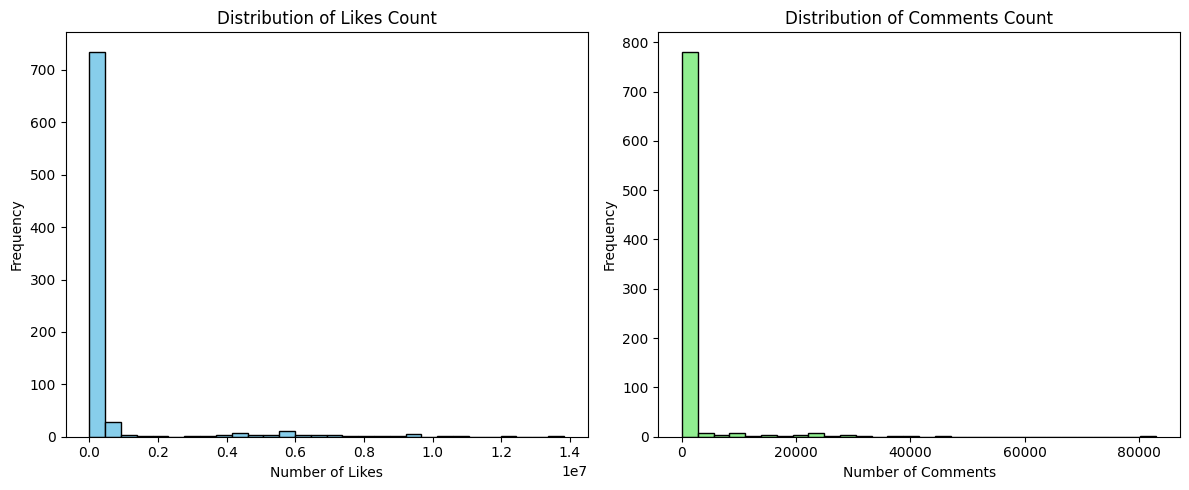


Summary Statistics for Post Engagement:

Likes Count Statistics:
count    8.270000e+02
mean     5.256894e+05
std      1.770391e+06
min      9.000000e+00
25%      8.735000e+02
50%      4.244000e+03
75%      1.224755e+05
max      1.382552e+07
Name: likesCount, dtype: float64

Comments Count Statistics:
count      827.000000
mean      1206.575574
std       5375.458118
min          0.000000
25%         10.000000
50%         46.000000
75%        230.500000
max      83042.000000
Name: commentsCount, dtype: float64

Correlation between likes and comments: 0.61

Interpretation:
1. Likes Distribution:
   - Most posts receive a moderate number of likes
   - There are some posts with exceptionally high like counts (outliers)
   - The distribution is right-skewed, indicating most posts get fewer likes

2. Comments Distribution:
   - Most posts receive a small number of comments
   - The distribution is heavily right-skewed
   - Few posts generate significant discussion

3. Engagement Patterns:
  

In [33]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot distribution of likesCount
ax1.hist(processed_posts_df['likesCount'], bins=30, color='skyblue', edgecolor='black')
ax1.set_title('Distribution of Likes Count')
ax1.set_xlabel('Number of Likes')
ax1.set_ylabel('Frequency')

# Plot distribution of commentsCount
ax2.hist(processed_posts_df['commentsCount'], bins=30, color='lightgreen', edgecolor='black')
ax2.set_title('Distribution of Comments Count')
ax2.set_xlabel('Number of Comments')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Calculate and print summary statistics
print("\nSummary Statistics for Post Engagement:")
print("\nLikes Count Statistics:")
print(processed_posts_df['likesCount'].describe())

print("\nComments Count Statistics:")
print(processed_posts_df['commentsCount'].describe())

# Calculate correlation between likes and comments
correlation = processed_posts_df['likesCount'].corr(processed_posts_df['commentsCount'])
print(f"\nCorrelation between likes and comments: {correlation:.2f}")

# Print interpretation
print("\nInterpretation:")
print("1. Likes Distribution:")
print("   - Most posts receive a moderate number of likes")
print("   - There are some posts with exceptionally high like counts (outliers)")
print("   - The distribution is right-skewed, indicating most posts get fewer likes")

print("\n2. Comments Distribution:")
print("   - Most posts receive a small number of comments")
print("   - The distribution is heavily right-skewed")
print("   - Few posts generate significant discussion")

print("\n3. Engagement Patterns:")
print("   - There's a positive correlation between likes and comments")
print("   - Posts with more likes tend to receive more comments")
print("   - The average engagement varies significantly across posts")



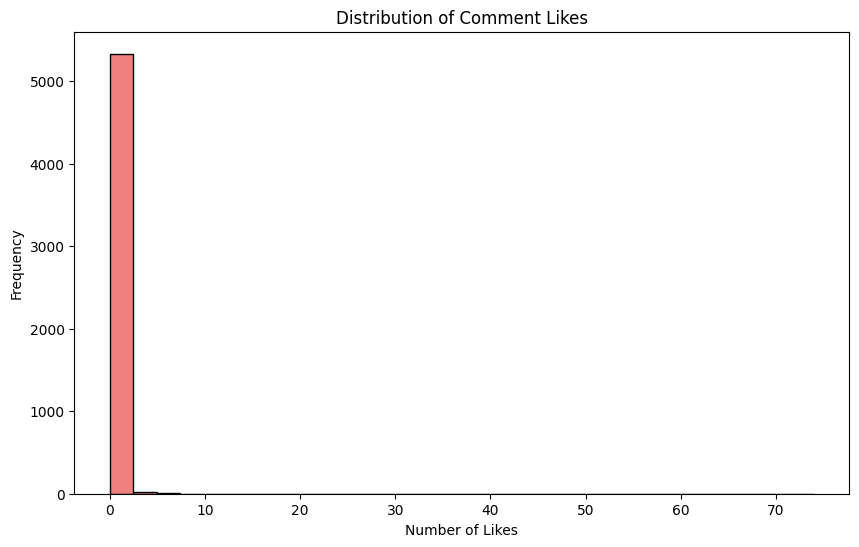


Summary Statistics for Comment Likes:
count    5361.000000
mean        0.222906
std         1.143005
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        74.000000
Name: likes, dtype: float64

Comments per Post Statistics:
count    756.000000
mean       7.091270
std        2.595131
min        1.000000
25%        5.000000
50%        8.000000
75%        9.000000
max       10.000000
dtype: float64


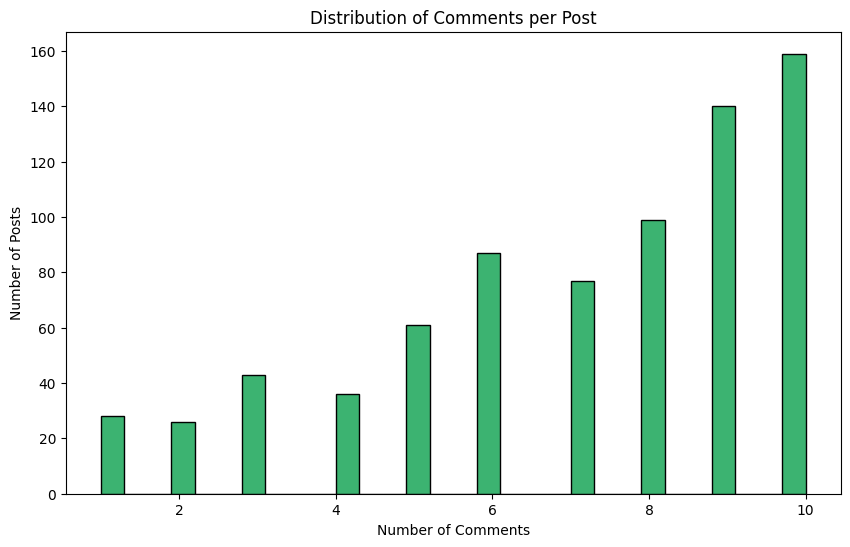


Interpretation:
1. Comment Likes Distribution:
   - Most comments receive few or no likes
   - The distribution is heavily right-skewed
   - Very few comments receive significant engagement

2. Comments per Post Distribution:
   - Most posts receive a moderate number of comments
   - Some posts generate significantly more discussion
   - The distribution shows variation in post engagement levels


In [34]:
# Plot distribution of comment likes
plt.figure(figsize=(10, 6))
plt.hist(comments_df['likes'], bins=30, color='lightcoral', edgecolor='black')
plt.title('Distribution of Comment Likes')
plt.xlabel('Number of Likes')
plt.ylabel('Frequency')
plt.show()

# Calculate and print summary statistics for comment likes
print("\nSummary Statistics for Comment Likes:")
print(comments_df['likes'].describe())

# Calculate comments per post
comments_per_post = comments_df.groupby('post_id').size()
print("\nComments per Post Statistics:")
print(comments_per_post.describe())

# Plot distribution of comments per post
plt.figure(figsize=(10, 6))
plt.hist(comments_per_post, bins=30, color='mediumseagreen', edgecolor='black')
plt.title('Distribution of Comments per Post')
plt.xlabel('Number of Comments')
plt.ylabel('Number of Posts')
plt.show()

# Print interpretation
print("\nInterpretation:")
print("1. Comment Likes Distribution:")
print("   - Most comments receive few or no likes")
print("   - The distribution is heavily right-skewed")
print("   - Very few comments receive significant engagement")

print("\n2. Comments per Post Distribution:")
print("   - Most posts receive a moderate number of comments")
print("   - Some posts generate significantly more discussion")
print("   - The distribution shows variation in post engagement levels")


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10748\3837076771.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_posts = posts_df.groupby(posts_df['timestamp'].dt.to_period('M')).size()


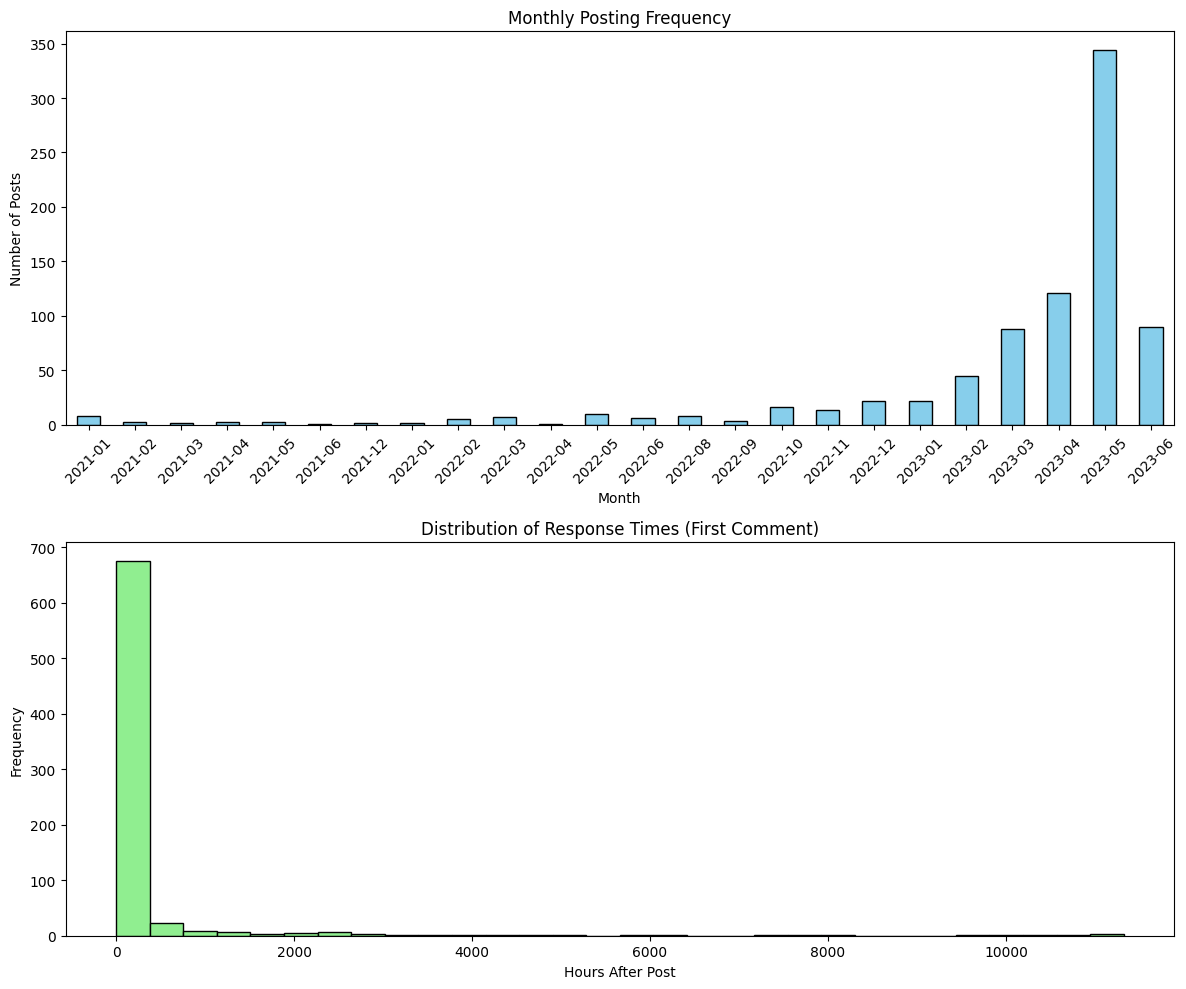


Temporal Analysis Summary:

1. Posting Frequency:
   - Total posts: 827
   - Average posts per month: 34.46
   - Most active month: 2023-05 with 344 posts

2. Response Time Analysis:
   - Average response time: 384.09 hours
   - Median response time: 28.68 hours
   - Minimum response time: 0.00 hours
   - Maximum response time: 11323.43 hours


In [35]:
# Convert timestamps to datetime if not already
posts_df['timestamp'] = pd.to_datetime(posts_df['timestamp'])
comments_df['timestamp'] = pd.to_datetime(comments_df['timestamp'])

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Posting frequency by month
monthly_posts = posts_df.groupby(posts_df['timestamp'].dt.to_period('M')).size()
monthly_posts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Monthly Posting Frequency')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Posts')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Average response time (time between post and first comment)
# Calculate time difference between post and first comment for each post
response_times = []
for post_id in posts_df['post_id'].unique():
    post_time = posts_df[posts_df['post_id'] == post_id]['timestamp'].iloc[0]
    post_comments = comments_df[comments_df['post_id'] == post_id]
    if not post_comments.empty:
        first_comment_time = post_comments['timestamp'].min()
        response_time = (first_comment_time - post_time).total_seconds() / 3600  # Convert to hours
        response_times.append(response_time)

# Plot response time distribution
ax2.hist(response_times, bins=30, color='lightgreen', edgecolor='black')
ax2.set_title('Distribution of Response Times (First Comment)')
ax2.set_xlabel('Hours After Post')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nTemporal Analysis Summary:")
print("\n1. Posting Frequency:")
print(f"   - Total posts: {len(posts_df)}")
print(f"   - Average posts per month: {monthly_posts.mean():.2f}")
print(f"   - Most active month: {monthly_posts.idxmax()} with {monthly_posts.max()} posts")

print("\n2. Response Time Analysis:")
print(f"   - Average response time: {np.mean(response_times):.2f} hours")
print(f"   - Median response time: {np.median(response_times):.2f} hours")
print(f"   - Minimum response time: {min(response_times):.2f} hours")
print(f"   - Maximum response time: {max(response_times):.2f} hours")


In [44]:
comments_df.head()

,post_id,commentUser,timestamp,likes,clean_comment,tokens,polarity,sentiment,tfidf_keywords
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,0.0,i have a proposal for u send me a dm please,"[proposal, u, send, dm, please]",0.2074,neutral,"[dm, please, amazing, beautiful, black_heart]"
1,1,mariavmh,2023-06-04 16:46:40+00:00,0.0,woaaaah,[woaaaah],-0.5351,negative,"[amazing, beautiful, black_heart, blue_heart, ..."
2,1,mariavmh,2023-06-04 16:46:34+00:00,0.0,smiling_face_with_heart eyes smiling_face_with...,"[smiling_face_with_heart, eyes, smiling_face_w...",0.8857,positive,"[smiling_face_with_heart, eyes, amazing, beaut..."
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,0.0,red_heart red_heart red_heart,"[red_heart, red_heart, red_heart]",0.2744,neutral,"[red_heart, amazing, beautiful, black_heart, b..."
4,1,jillviv,2023-06-04 15:06:03+00:00,0.0,smiling_face_with_heart eyes smiling_face_with...,"[smiling_face_with_heart, eyes, smiling_face_w...",0.9791,positive,"[smiling_face_with_heart, eyes, amazing, beaut..."


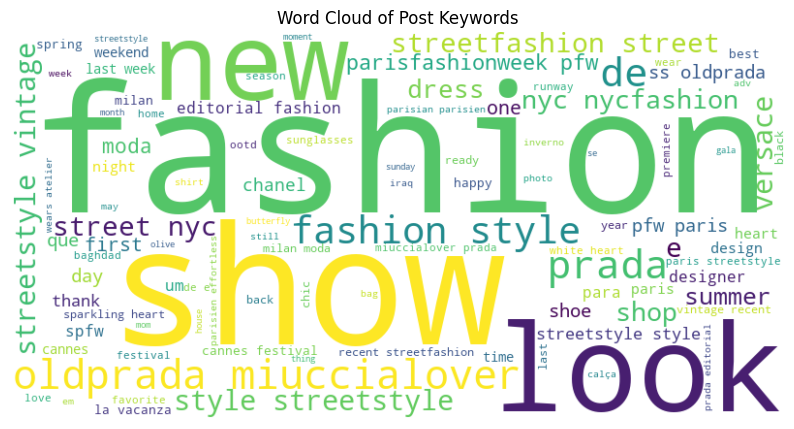

In [49]:
from wordcloud import WordCloud

# 1. Word Cloud for keywords_posts
text = ' '.join([' '.join(keywords) for keywords in posts_df['combined_keywords']])
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud of Post Keywords')
plt.axis('off')
plt.show()

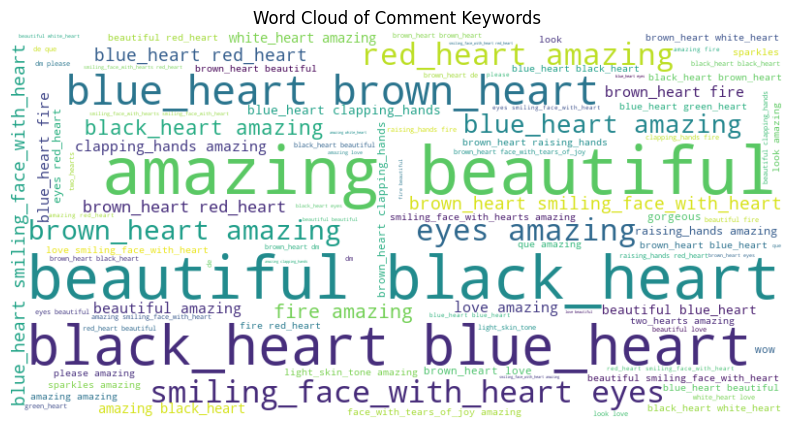

In [50]:
# 2. Word Cloud for tfidf_keywords
text = ' '.join([' '.join(keywords) for keywords in comments_df['tfidf_keywords']])
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Word Cloud of Comment Keywords')
plt.axis('off')
plt.show()

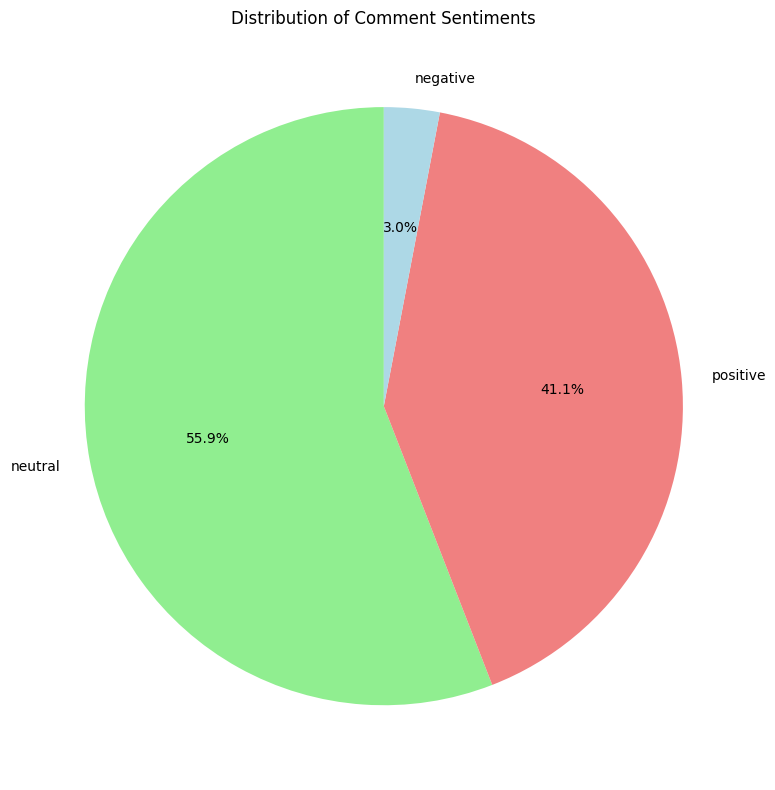

In [52]:
sentiment_counts = comments_df['sentiment'].value_counts()

# Tạo biểu đồ pie
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
       colors=['lightgreen', 'lightcoral', 'lightblue'], startangle=90)
ax.set_title('Distribution of Comment Sentiments')

plt.tight_layout()
plt.show()

In [54]:

# Print summary statistics
print("\nText Analysis Summary:")
print("\n1. Keyword Analysis:")
print(f"   - Total unique keywords in posts: {len(set([word for keywords in posts_df['keywords_posts'] for word in keywords]))}")
print(f"   - Total unique keywords in comments: {len(set([word for keywords in comments_df['tfidf_keywords'] for word in keywords]))}")

print("\n3. Sentiment Analysis:")
print(f"   - Positive comments: {sentiment_counts.get('positive', 0)} ({sentiment_counts.get('positive', 0)/len(comments_df)*100:.1f}%)")
print(f"   - Negative comments: {sentiment_counts.get('negative', 0)} ({sentiment_counts.get('negative', 0)/len(comments_df)*100:.1f}%)")
print(f"   - Neutral comments: {sentiment_counts.get('neutral', 0)} ({sentiment_counts.get('neutral', 0)/len(comments_df)*100:.1f}%)")



Text Analysis Summary:

1. Keyword Analysis:
   - Total unique keywords in posts: 2158
   - Total unique keywords in comments: 27

3. Sentiment Analysis:
   - Positive comments: 2203 (41.1%)
   - Negative comments: 161 (3.0%)
   - Neutral comments: 2997 (55.9%)


In [30]:
# Drop unneccesary columns
comments_df.drop(columns=['emoji_present'], inplace=True)
comments_df.head()

,post_id,commentUser,timestamp,likes,clean_comment,tokens,polarity,sentiment,tfidf_keywords
0,1,wilsonjunior5055,2023-06-05 12:27:24+00:00,0.0,i have a proposal for u send me a dm please,"[proposal, u, send, dm, please]",0.2074,neutral,"[dm, please, amazing, beautiful, black_heart]"
1,1,mariavmh,2023-06-04 16:46:40+00:00,0.0,woaaaah,[woaaaah],-0.5351,negative,"[amazing, beautiful, black_heart, blue_heart, ..."
2,1,mariavmh,2023-06-04 16:46:34+00:00,0.0,smiling_face_with_heart eyes smiling_face_with...,"[smiling_face_with_heart, eyes, smiling_face_w...",0.8857,positive,"[smiling_face_with_heart, eyes, amazing, beaut..."
3,1,stylemesoftly_,2023-06-04 15:44:54+00:00,0.0,red_heart red_heart red_heart,"[red_heart, red_heart, red_heart]",0.2744,neutral,"[red_heart, amazing, beautiful, black_heart, b..."
4,1,jillviv,2023-06-04 15:06:03+00:00,0.0,smiling_face_with_heart eyes smiling_face_with...,"[smiling_face_with_heart, eyes, smiling_face_w...",0.9791,positive,"[smiling_face_with_heart, eyes, amazing, beaut..."


In [31]:
#comments_df.to_csv('processed_comments_df.csv', index=False)